In [ ]:
# ============================================================
# CELLULE 1 — Installation corrigée
# ============================================================

!pip install PyMuPDF          # ← installe fitz (le vrai nom du package)
!pip install pyarabic         # ← installe pyarabic.araby
!pip install scikit-learn
!pip install pandas

In [ ]:

import re
import pandas as pd
import fitz                          # vient de PyMuPDF ✅
import pyarabic.araby as araby       # vient de pyarabic ✅
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

In [ ]:
# ============================================================
# CELLULE 3 — Extraction du texte brut depuis le PDF
# ============================================================

def extraire_texte_pdf(chemin_pdf):
    """Lit toutes les pages du PDF et retourne le texte complet."""
    doc = fitz.open(chemin_pdf)
    texte_complet = ""
    for page in doc:
        texte_complet += page.get_text()
    return texte_complet

# --- Utilisation ---
texte_brut = extraire_texte_pdf("code de la route MA52_05.pdf")  # mets le vrai nom de ton fichier

# Afficher les 500 premiers caractères pour vérifier
print(texte_brut[:500])

تم إعداد هذه النسخة من أجل تسهيل 
مقروئية النص، وال يحتج إال بالنصوص 
في صيغتها املنشورة بالجريدة الرسمية
  المتعلق52.05 القانون رقم
،بمدونة السير على الطرق
كما وقع تغييره وتتميمه
صيغة موطدة بتاريخ
2024 يوليو10
1
األمانة العامة للحكومة
 52.05 القانون رقم
 1.10.07 املتعلق بمدونة السير على الطرق الصادر بتنفيذه الظهير الشريف رقم
،)2010  فبراير11( 1431  من صفر26 بتاريخ
كما وقع تغييره وتتميمه
)2168 : )، ص2010  مارس25(1431  ربيع اآلخر8  بتاريخ5824 ج.ر عدد(
الكتاب األول
شروط السير على الطريق العمومية
ا


In [ ]:
len(texte_brut)

223736

In [ ]:
# ============================================================
# CELLULE 4 — Normalisation
# ============================================================

def normaliser_texte_arabe(texte):

    # Étape 1 : Supprimer les Tashkeel (voyelles)
    texte = araby.strip_tashkeel(texte)

    # Étape 2 : Normaliser les Alef (أ إ آ → ا)  ← CORRECTION ICI
    texte = araby.normalize_alef(texte)

    # Étape 3 : Normaliser la Ta Marbuta (ة → ه)
    texte = araby.normalize_teh(texte)

    # Étape 4 : Supprimer les caractères spéciaux inutiles
    texte = re.sub(r'[^\u0600-\u06FF\s\d\.\,]', ' ', texte)

    # Étape 5 : Supprimer les espaces multiples
    texte = re.sub(r'\s+', ' ', texte).strip()

    return texte

# --- Test ---
exemple = "سَيَّارَةٌ أو إِمَارَةٍ"
print("Avant :", exemple)
print("Après :", normaliser_texte_arabe(exemple))

print("\n--- Séparateur ---\n")

texte_normalise = normaliser_texte_arabe(texte_brut)
print(texte_normalise[:500])

Avant : سَيَّارَةٌ أو إِمَارَةٍ
Après : سياره او اماره

--- Séparateur ---

تم اعداد هذه النسخه من اجل تسهيل مقروئيه النص، وال يحتج اال بالنصوص في صيغتها املنشوره بالجريده الرسميه المتعلق52.05 القانون رقم ،بمدونه السير علا الطرق كما وقع تغييره وتتميمه صيغه موطده بتاريخ 2024 يوليو10 1 االمانه العامه للحكومه 52.05 القانون رقم 1.10.07 املتعلق بمدونه السير علا الطرق الصادر بتنفيذه الظهير الشريف رقم ، 2010 فبراير11 1431 من صفر26 بتاريخ كما وقع تغييره وتتميمه 2168 ، ص2010 مارس25 1431 ربيع االخر8 بتاريخ5824 ج.ر عدد الكتاب االول شروط السير علا الطريق العموميه القسم االول رخصه ا


In [ ]:
# ============================================================
# CELLULE 5 — Segmentation  (pattern RTL)
# ============================================================

def segmenter_en_articles(texte):
    """
    Dans ce PDF, le format RTL donne : "13 املاده"
    Donc le pattern est : \d+ suivi de املاده
    """

    # Pattern corrigé : numéro AVANT le mot (effet RTL)
    pattern = r'(\d+\s+املاده)'

    parties = re.split(pattern, texte)

    articles = []

    for i in range(1, len(parties) - 1, 2):
        titre   = parties[i].strip()
        contenu = parties[i+1].strip()

        # Extraire le numéro
        numero = re.search(r'\d+', titre)
        numero = numero.group() if numero else "?"

        articles.append({
            'article_id' : numero,
            'texte_brut' : titre + " " + contenu
        })

    return articles

# --- Appliquer ---
articles = segmenter_en_articles(texte_normalise)

print(f"Nombre d'articles trouvés : {len(articles)}")
print("\n--- 3 premiers articles ---\n")
for art in articles[:3]:
    print(f"Article {art['article_id']} :")
    print(art['texte_brut'][:300])
    print("-" * 50)

Nombre d'articles trouvés : 336

--- 3 premiers articles ---

Article 1 :
1 املاده ال يجوز الي شخص ان يسوق مركبه ذات محرك او مجموعه مركبات علا الطريق العموميه ما لم يكن حاصال علا رخصه للسياقه ساريه الصالحيه ومسلمه من قبل االداره، تناسب صنف .املركبه او مجموعه املركبات التي يسوقها
--------------------------------------------------
Article 2 :
2 املاده استثناء من احكام املاده االولا اعاله يجوز للمغاربه القاطنين بالخارج ان يسوقوا، داخل التراب الوطني، خالل مده اقصاها 1 سنه واحده ابتداء من اقامتهم باملغرب، بواسطه رخصه السياقه املسلمه لهم بالخارج ساريه الصالحيه ؛ يجوز للسائقين من جنسيه اجنبيه، ان يسوقوا بواسطه رخصه السياقه املسلمه لهم بالخارج
--------------------------------------------------
Article 3 :
3 املاده يجب علا السائقين الحاصلين علا رخصه سياقه مسلمه بالخارج، بعد انصرام املده املشار اليها في املاده السابقه، ان يتقدموا المتحانات الحصول علا رخصه السياقه املغربيه، او ان يطلبوا تبديل .رخصتهم للسياقه تطبيقا للفقرات املواليه يمكن للمغاربه واالجانب الحاصلين علا رخصه سياقه مسلمه من قبل دوله 

<>:8: SyntaxWarning: invalid escape sequence '\d'
<>:8: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_16216/2499613586.py:8: SyntaxWarning: invalid escape sequence '\d'
  Donc le pattern est : \d+ suivi de املاده


In [ ]:
# ============================================================
# CELLULE 6 — Version définitive corrigée
# ============================================================

MOIS_HIJRI = [
    'محرم', 'صفر', 'ربيع', 'جمادا', 'رجب',
    'شعبان', 'رمضان', 'شوال', 'ذي القعده', 'ذي الحجه'
]

# Montants en lettres → chiffres (version corrigée, sans "مائه" seul)
MONTANTS_LETTRES = {
    'خمسه وعشرون'       : 25,
    'مائتين'             : 200,
    'ثالثمائه'           : 300,
    'اربعمائه'           : 400,
    'خمسمائه'            : 500,
    'ستمائه'             : 600,
    'سبعمائه'            : 700,
    'الف ومائتين'        : 1200,
    'الف وخمسمائه'       : 1500,
    'الفين'              : 2000,
    'الفين وخمسمائه'     : 2500,
    'ثالثه االف'         : 3000,
    'اربعه االف'         : 4000,
    'خمسه االف'          : 5000,
    'سبعه االف وخمسمائه' : 7500,
    'ثمانيه االف'        : 8000,
    'عشره االف'          : 10000,
    'عشرين الف'          : 20000,
    'ثالثين الف'         : 30000,
    'خمسين الف'          : 50000,
    'ستين الف'           : 60000,
    'مائه الف'           : 100000,  # ← مائه هنا = 100.000 DH ✅
}

# Points en lettres → chiffres
POINTS_LETTRES = {
    'اربع نقط'       : 4,
    'ست نقط'         : 6,
    'ثماني نقط'      : 8,
    'عشر نقط'        : 10,
    'اثنتي عشره نقطه': 12,
    'اربع عشره نقطه' : 14,
    'ست عشره نقطه'   : 16,
}

def est_faux_positif(valeur_str, contexte):
    """Filtre les faux positifs : années Hijri, poids, distances."""
    try:
        n = int(valeur_str.replace('.', ''))
    except:
        return True
    # Filtrer années Hijri
    if 1400 <= n <= 1450 and any(m in contexte for m in MOIS_HIJRI):
        return True
    # Filtrer poids (كيلوغرام) et cylindrées (مكعبا)
    if any(mot in contexte for mot in ['كيلوغرام', 'مكعبا', 'كلم', 'كيلومتر']):
        return True
    return False

def nettoyer_nombre(s):
    try:
        return int(s.replace('.', ''))
    except:
        return None

def extraire_amende(texte):
    candidats = []

    # --- Sens 1 : nombre AVANT درهم ---
    for m in re.finditer(r'([\d]+(?:\.[\d]{3})?)\s{0,5}درهم', texte):
        debut = max(0, m.start() - 60)
        fin   = min(len(texte), m.end() + 40)
        contexte = texte[debut:fin]
        if not est_faux_positif(m.group(1), contexte):
            v = nettoyer_nombre(m.group(1))
            if v and 100 <= v <= 500000:
                candidats.append(v)

    # --- Sens 2 : nombre APRÈS درهم (RTL) ---
    for m in re.finditer(r'درهم\s{0,5}([\d]+(?:\.[\d]{3})?)', texte):
        debut = max(0, m.start() - 60)
        fin   = min(len(texte), m.end() + 40)
        contexte = texte[debut:fin]
        if not est_faux_positif(m.group(1), contexte):
            v = nettoyer_nombre(m.group(1))
            if v and 100 <= v <= 500000:
                candidats.append(v)

    # --- Sens 3 : montants en lettres ---
    for mot, valeur in MONTANTS_LETTRES.items():
        if mot in texte and 'درهم' in texte:
            candidats.append(valeur)

    return min(candidats) if candidats else None


def extraire_points(texte):
    # Sens RTL : "نقطه20" ou "نقطه 20"
    m = re.search(r'نقط[ه]?\s*(\d+)', texte)
    if m:
        return int(m.group(1))

    # Sens normal : "4 نقط" ou "20 نقطه"
    m = re.search(r'(\d+)\s*نقط[ه]?', texte)
    if m:
        val = int(m.group(1))
        # Filtrer les faux positifs (ex: numéros d'articles)
        if 1 <= val <= 30:
            return val

    # Points en lettres
    for mot, valeur in POINTS_LETTRES.items():
        if mot in texte:
            return valeur

    return None


def extraire_entites(article):
    texte = article['texte_brut']

    amende = extraire_amende(texte)
    points = extraire_points(texte)

    # Catégorie véhicule
    categories = {
        'poids_lourd': ['شاحنه', 'مركبه ثقيله', 'حافله', 'شاحنات'],
        'moto'       : ['دراجه ناريه', 'موتو'],
        'leger'      : ['سياره', 'مركبه', 'سياقه']
    }
    categorie = None
    for cat, mots_cles in categories.items():
        if any(mot in texte for mot in mots_cles):
            categorie = cat
            break

    # Type d'infraction
    if any(mot in texte for mot in ['يعاقب', 'غرامه', 'سجن', 'حبس', 'عقوبه']):
        type_inf = 'sanction'
    elif any(mot in texte for mot in ['يجب', 'يلتزم', 'يتعين', 'يمنع', 'يحظر']):
        type_inf = 'obligation'
    else:
        type_inf = 'definition'

    # Mots clés
    mots_tags = {
        'vitesse'       : ['سرعه', 'السرعه'],
        'stationnement' : ['توقف', 'وقوف', 'ركن'],
        'alcool'        : ['كحول', 'سكر', 'تحليل الدم'],
        'nuit'          : ['ليل', 'مصابيح'],
        'autoroute'     : ['طريق سيار', 'اوتوستراد'],
        'telephone'     : ['هاتف', 'جوال'],
        'ceinture'      : ['حزام'],
        'depassement'   : ['تجاوز'],
        'feux'          : ['اشاره ضوئيه', 'ضوء احمر'],
        'documents'     : ['رخصه', 'تامين', 'وثيقه']
    }
    tags = [tag for tag, mots in mots_tags.items()
            if any(mot in texte for mot in mots)]

    return {
        'article_id'        : article['article_id'],
        'infraction_desc'   : texte[:250],
        'amende_fixe'       : amende,
        'points_retrait'    : points,
        'categorie_vehicule': categorie,
        'type_infraction'   : type_inf,
        'mots_cles'         : ', '.join(tags) if tags else None
    }

# --- Appliquer ---
donnees_extraites = [extraire_entites(art) for art in articles]

# --- Statistiques ---
avec_amende = [d for d in donnees_extraites if d['amende_fixe']]
avec_points = [d for d in donnees_extraites if d['points_retrait']]
sanctions   = [d for d in donnees_extraites if d['type_infraction'] == 'sanction']

print(f"Total articles          : {len(donnees_extraites)}")
print(f"Avec amende trouvée     : {len(avec_amende)}")
print(f"Avec points retrait     : {len(avec_points)}")
print(f"Classifiés 'sanction'   : {len(sanctions)}")

print("\n--- 5 exemples avec amende ---\n")
for d in avec_amende[:5]:
    print(f"  Art.{d['article_id']:>4} | "
          f"{str(d['amende_fixe']):>7} DH | "
          f"pts={str(d['points_retrait']):>3} | "
          f"{d['type_infraction']}")

Total articles          : 336
Avec amende trouvée     : 69
Avec points retrait     : 5
Classifiés 'sanction'   : 106

--- 5 exemples avec amende ---

  Art. 118 |     500 DH | pts=None | sanction
  Art. 119 |    5000 DH | pts=None | sanction
  Art. 126 |    2000 DH | pts=None | sanction
  Art. 127 |    2000 DH | pts=None | sanction
  Art. 143 |     200 DH | pts=None | sanction


In [ ]:
# ============================================================
# CELLULE 7 — Création du DataFrame et export CSV
# ============================================================

df = pd.DataFrame(donnees_extraites)

# Aperçu
print("=== Aperçu du DataFrame ===\n")
print(df.head(10).to_string())

print(f"\n=== Shape : {df.shape} ===")
print(f"({df.shape[0]} lignes × {df.shape[1]} colonnes)")

print("\n=== Distribution par type d'infraction ===")
print(df['type_infraction'].value_counts())

print("\n=== Distribution par catégorie véhicule ===")
print(df['categorie_vehicule'].value_counts())

print("\n=== Amendes disponibles ===")
print(df[df['amende_fixe'].notna()][['article_id','amende_fixe','type_infraction']].head(10))

=== Aperçu du DataFrame ===

  article_id                                                                                                                                                                                                                                             infraction_desc  amende_fixe  points_retrait categorie_vehicule type_infraction               mots_cles
0          1                                               1 املاده ال يجوز الي شخص ان يسوق مركبه ذات محرك او مجموعه مركبات علا الطريق العموميه ما لم يكن حاصال علا رخصه للسياقه ساريه الصالحيه ومسلمه من قبل االداره، تناسب صنف .املركبه او مجموعه املركبات التي يسوقها          NaN             NaN              leger      definition               documents
1          2  2 املاده استثناء من احكام املاده االولا اعاله يجوز للمغاربه القاطنين بالخارج ان يسوقوا، داخل التراب الوطني، خالل مده اقصاها 1 سنه واحده ابتداء من اقامتهم باملغرب، بواسطه رخصه السياقه املسلمه لهم بالخارج ساريه الصالحيه ؛ يجوز للسائقين من جنسيه اجنبيه، 

In [ ]:
# ============================================================
# CELLULE 8 — Nettoyage final + Export CSV
# ============================================================

# Copie propre du DataFrame
df_final = df.copy()

# --- Nettoyage 1 : filtrer points aberrants (max réel = 30) ---
df_final['points_retrait'] = df_final['points_retrait'].apply(
    lambda x: x if (x is not None and isinstance(x, int) and 1 <= x <= 30) else None
)

# --- Nettoyage 2 : article_id en entier ---
df_final['article_id'] = pd.to_numeric(df_final['article_id'], errors='coerce')
df_final = df_final.dropna(subset=['article_id'])
df_final['article_id'] = df_final['article_id'].astype(int)

# --- Nettoyage 3 : trier par numéro d'article ---
df_final = df_final.sort_values('article_id').reset_index(drop=True)

# --- Nettoyage 4 : nettoyer infraction_desc (supprimer métadonnées) ---
# Supprimer les références légales répétitives en début de description
pattern_meta = r'(من\d+\s+بتاريخ[\d\.]+.*?شوال\s*)'
df_final['infraction_desc'] = df_final['infraction_desc'].apply(
    lambda x: re.sub(pattern_meta, '', str(x)).strip()
)

# --- Export CSV ---
df_final.to_csv('export_final.csv', index=False, encoding='utf-8-sig')

# --- Vérification finale ---
print("✅ Fichier export_final.csv créé avec succès !\n")
print(f"   Lignes totales      : {len(df_final)}")
print(f"   Avec amende         : {df_final['amende_fixe'].notna().sum()}")
print(f"   Avec points         : {df_final['points_retrait'].notna().sum()}")
print(f"   Avec mots clés      : {df_final['mots_cles'].notna().sum()}")

print("\n=== Aperçu des articles avec sanctions ===\n")
sanctions = df_final[df_final['type_infraction'] == 'sanction'][
    ['article_id', 'amende_fixe', 'points_retrait', 'mots_cles']
].dropna(subset=['amende_fixe'])

print(sanctions.head(10).to_string(index=False))

print("\n=== Premières lignes du CSV ===\n")
print(df_final[['article_id', 'type_infraction',
                'amende_fixe', 'categorie_vehicule']].head(10).to_string())

✅ Fichier export_final.csv créé avec succès !

   Lignes totales      : 336
   Avec amende         : 69
   Avec points         : 0
   Avec mots clés      : 192

=== Aperçu des articles avec sanctions ===

 article_id  amende_fixe points_retrait mots_cles
        118        500.0           None documents
        119       5000.0           None      None
        126       2000.0           None documents
        127       2000.0           None documents
        143        200.0           None      None
        148       2000.0           None documents
        150       5000.0           None documents
        151       2000.0           None documents
        152       8000.0           None documents
        152       4000.0           None documents

=== Premières lignes du CSV ===

   article_id type_infraction  amende_fixe categorie_vehicule
0           1      definition          NaN              leger
1           2      definition          NaN              leger
2           3      obliga

In [ ]:
# ============================================================
# CELLULE 9 — TF-IDF corrigé (avec stopwords arabes)
# ============================================================

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

# --- Stopwords arabes ---
STOPWORDS_AR = [
    'من', 'في', 'او', 'علا', 'الا', 'ان', 'كل', 'هذا', 'هذه',
    'اعاله', 'التي', 'الذي', 'عن', 'على', 'اذا', 'عليها', 'قبل',
    'بعد', 'مع', 'لم', 'لن', 'قد', 'كان', 'كانت', 'يكون', 'تكون',
    'له', 'لها', 'لهم', 'بها', 'به', 'بهم', 'منه', 'منها', 'عنه',
    'حتى', 'حيث', 'اي', 'اما', 'ايضا', 'فقط', 'غير', 'دون',
    'القانون', 'احكام', 'النصوص', 'تطبيقه', 'الصادره',
    '000', '1437', '1431', '2016', '2010'
]

# --- TF-IDF avec stopwords ---
vectorizer = TfidfVectorizer(
    min_df       = 2,
    max_df       = 0.8,
    max_features = 500,
    stop_words   = STOPWORDS_AR
)

textes = df_final['infraction_desc'].fillna('').tolist()
X = vectorizer.fit_transform(textes)

print(f"Matrice TF-IDF : {X.shape}")

# --- Top 20 mots UTILES ---
mots   = vectorizer.get_feature_names_out()
scores = X.sum(axis=0).A1
top_indices = scores.argsort()[::-1][:20]

print("\n=== Top 20 mots les plus importants (sans stopwords) ===\n")
for i in top_indices:
    print(f"  {mots[i]:25s} → score : {scores[i]:.2f}")

Matrice TF-IDF : (336, 500)

=== Top 20 mots les plus importants (sans stopwords) ===

  السياقه                   → score : 13.42
  رخصه                      → score : 13.16
  االداره                   → score : 12.58
  يجب                       → score : 12.02
  يعاقب                     → score : 8.84
  يمكن                      → score : 8.67
  درهم                      → score : 8.56
  ال                        → score : 8.27
  حاله                      → score : 8.26
  مركبه                     → score : 8.22
  العموميه                  → score : 7.70
  املركبه                   → score : 7.53
  املنصوص                   → score : 7.42
  املركبات                  → score : 7.38
  املخالفه                  → score : 7.03
  الصادر                    → score : 6.69
  الطريق                    → score : 6.65
  رقم                       → score : 6.60
  املشار                    → score : 6.47
  بغرامه                    → score : 6.37


In [ ]:
# ============================================================
# CELLULE 10 — Clustering KMeans
# ============================================================

# --- Étape 1 : Choisir le nombre de groupes ---
# On choisit 6 groupes : permis, sanctions, vitesse,
#                        stationnement, technique, administratif
N_CLUSTERS = 6

kmeans = KMeans(
    n_clusters  = N_CLUSTERS,
    random_state= 42,
    n_init      = 10
)
kmeans.fit(X)

# Ajouter le cluster au DataFrame
df_final['cluster'] = kmeans.labels_

print(f"✅ Clustering terminé — {N_CLUSTERS} groupes\n")

# --- Étape 2 : Identifier chaque groupe ---
print("=== Mots caractéristiques de chaque groupe ===\n")

# Centres des clusters → mots les plus représentatifs
centres    = kmeans.cluster_centers_
mots_vocab = vectorizer.get_feature_names_out()

noms_clusters = {}

for i in range(N_CLUSTERS):
    # Top 5 mots du cluster
    top5_idx  = centres[i].argsort()[::-1][:5]
    top5_mots = [mots_vocab[j] for j in top5_idx]

    print(f"  Groupe {i} : {' | '.join(top5_mots)}")
    noms_clusters[i] = top5_mots[0]  # nom = mot le plus représentatif

# --- Étape 3 : Statistiques par groupe ---
print("\n=== Taille de chaque groupe ===\n")
print(df_final['cluster'].value_counts().sort_index().to_string())

# --- Étape 4 : Exemples par groupe ---
print("\n=== Exemple d'article par groupe ===\n")
for i in range(N_CLUSTERS):
    exemple = df_final[df_final['cluster'] == i].iloc[0]
    print(f"Groupe {i} ({noms_clusters[i]}) :")
    print(f"  Art.{exemple['article_id']} — {exemple['infraction_desc'][:120]}")
    print()

✅ Clustering terminé — 6 groupes

=== Mots caractéristiques de chaque groupe ===

  Groupe 0 : السياقه | يجب | االداره | رخصه | حاله
  Groupe 1 : يعاقب | درهم | بغرامه | خمسه | االخالل
  Groupe 2 : يمكن | اال | ال | حامل | الكتروني
  Groupe 3 : املركبات | العموميه | الطريق | قواعد | ذات
  Groupe 4 : تاريخ | حيز | التنفيذ | دخول | اجل
  Groupe 5 : رقم | الصادر | 14 | يوليو18 | اغسطس11

=== Taille de chaque groupe ===

cluster
0    174
1     51
2     24
3     38
4     16
5     33

=== Exemple d'article par groupe ===

Groupe 0 (السياقه) :
  Art.2 — 2 املاده استثناء من احكام املاده االولا اعاله يجوز للمغاربه القاطنين بالخارج ان يسوقوا، داخل التراب الوطني، خالل مده اقص

Groupe 1 (يعاقب) :
  Art.119 — 119 املاده كل مالك مركبه اجنبيه، التتوفر علا رقم تسجيل مغربي، يقوم بعمليه النقل بين نقطتين داخل التراب املغربي، دون ترخي

Groupe 2 (يمكن) :
  Art.3 — 3 املاده يجب علا السائقين الحاصلين علا رخصه سياقه مسلمه بالخارج، بعد انصرام املده املشار اليها في املاده السابقه، ان يتق

Groupe 3 (املركبات) :


In [ ]:
# ============================================================
# CELLULE 11 — Nommer les clusters + CSV final
# ============================================================

# Noms humains pour chaque cluster
noms_groupes = {
    0 : 'permis_conduite',
    1 : 'sanctions_amendes',
    2 : 'permissions_exceptions',
    3 : 'regles_circulation',
    4 : 'dispositions_transitoires',
    5 : 'references_legales'
}

df_final['categorie_cluster'] = df_final['cluster'].map(noms_groupes)

# --- Export CSV final complet ---
df_final.to_csv('export_final.csv', index=False, encoding='utf-8-sig')

print("✅ export_final.csv mis à jour !\n")
print(f"Colonnes finales : {df_final.columns.tolist()}\n")

# --- Résumé par cluster ---
print("=== Résumé par catégorie ===\n")
resume = df_final.groupby('categorie_cluster').agg(
    nb_articles   = ('article_id',   'count'),
    avec_amende   = ('amende_fixe',  lambda x: x.notna().sum()),
    amende_moy    = ('amende_fixe',  'mean'),
    amende_max    = ('amende_fixe',  'max'),
).round(0)
print(resume.to_string())

# --- Focus sur les sanctions ---
print("\n=== Top 10 sanctions (amendes les plus élevées) ===\n")
top_sanctions = df_final[df_final['amende_fixe'].notna()]\
    .sort_values('amende_fixe', ascending=False)\
    [['article_id', 'amende_fixe', 'categorie_cluster', 'mots_cles']]\
    .head(10)
print(top_sanctions.to_string(index=False))

✅ export_final.csv mis à jour !

Colonnes finales : ['article_id', 'infraction_desc', 'amende_fixe', 'points_retrait', 'categorie_vehicule', 'type_infraction', 'mots_cles', 'cluster', 'categorie_cluster']

=== Résumé par catégorie ===

                           nb_articles  avec_amende  amende_moy  amende_max
categorie_cluster                                                          
dispositions_transitoires           16            0         NaN         NaN
permis_conduite                    174            7      3086.0     15000.0
permissions_exceptions              24            1        25.0        25.0
references_legales                  33           10     27852.0    100000.0
regles_circulation                  38            2       400.0       500.0
sanctions_amendes                   51           49      8086.0    100000.0

=== Top 10 sanctions (amendes les plus élevées) ===

 article_id  amende_fixe  categorie_cluster                mots_cles
        164     100000.0 referenc

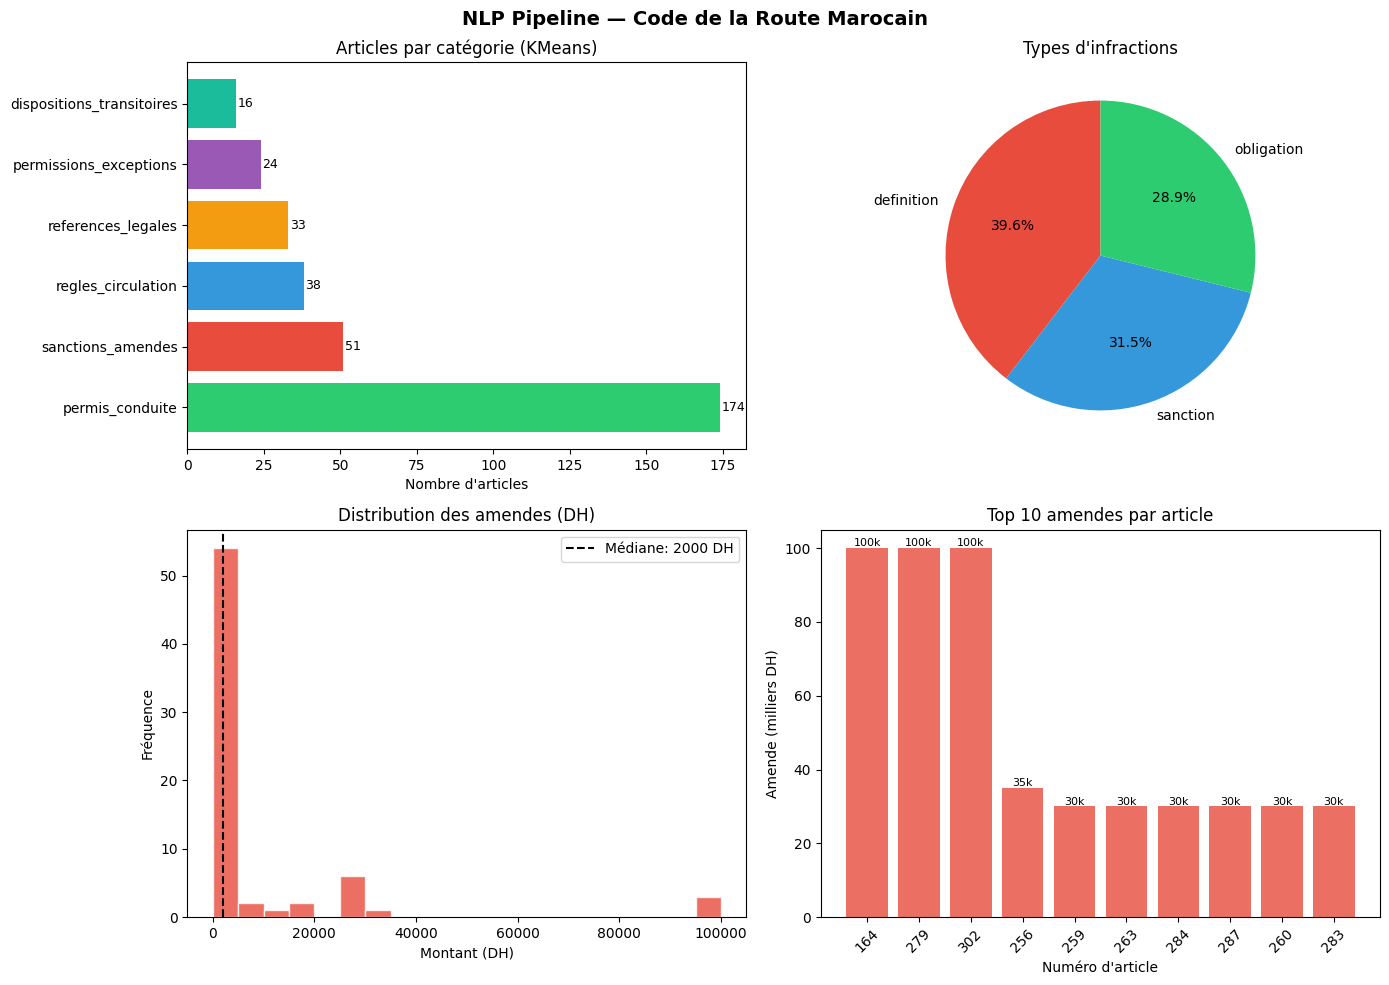

✅ Graphique sauvegardé : nlp_pipeline_results.png


In [ ]:
# ============================================================
# CELLULE 12 — Visualisation des résultats
# ============================================================

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('NLP Pipeline — Code de la Route Marocain',
             fontsize=14, fontweight='bold')

# --- Graphique 1 : Articles par catégorie cluster ---
ax1 = axes[0, 0]
counts = df_final['categorie_cluster'].value_counts()
colors = ['#2ecc71','#e74c3c','#3498db','#f39c12','#9b59b6','#1abc9c']
ax1.barh(counts.index, counts.values, color=colors)
ax1.set_title('Articles par catégorie (KMeans)')
ax1.set_xlabel('Nombre d\'articles')
for i, v in enumerate(counts.values):
    ax1.text(v + 0.5, i, str(v), va='center', fontsize=9)

# --- Graphique 2 : Distribution des types d'infractions ---
ax2 = axes[0, 1]
types = df_final['type_infraction'].value_counts()
ax2.pie(types.values, labels=types.index, autopct='%1.1f%%',
        colors=['#e74c3c','#3498db','#2ecc71'],
        startangle=90)
ax2.set_title('Types d\'infractions')

# --- Graphique 3 : Distribution des amendes ---
ax3 = axes[1, 0]
amendes = df_final['amende_fixe'].dropna()
ax3.hist(amendes, bins=20, color='#e74c3c', edgecolor='white', alpha=0.8)
ax3.set_title('Distribution des amendes (DH)')
ax3.set_xlabel('Montant (DH)')
ax3.set_ylabel('Fréquence')
ax3.axvline(amendes.median(), color='black', linestyle='--',
            label=f'Médiane: {int(amendes.median())} DH')
ax3.legend()

# --- Graphique 4 : Top amendes par article ---
ax4 = axes[1, 1]
top10 = df_final.dropna(subset=['amende_fixe'])\
               .sort_values('amende_fixe', ascending=False)\
               .head(10)
bars = ax4.bar(top10['article_id'].astype(str),
               top10['amende_fixe'] / 1000,
               color='#e74c3c', alpha=0.8)
ax4.set_title('Top 10 amendes par article')
ax4.set_xlabel('Numéro d\'article')
ax4.set_ylabel('Amende (milliers DH)')
ax4.tick_params(axis='x', rotation=45)
for bar, val in zip(bars, top10['amende_fixe']):
    ax4.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'{int(val/1000)}k', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('nlp_pipeline_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graphique sauvegardé : nlp_pipeline_results.png")

In [ ]:
# ============================================================
# CELLULE 13 — Résumé exécutif du pipeline
# ============================================================

print("=" * 60)
print("   PIPELINE NLP — CODE DE LA ROUTE MAROCAIN")
print("   Résumé des résultats")
print("=" * 60)

print(f"""
📄 SOURCE
   Fichier     : Code de la Route (Loi 52.05)
   Langue      : Arabe (RTL)
   Pages       : PDF complet

📊 EXTRACTION (Regex Rules-based)
   Articles extraits    : {len(df_final)}
   Amendes trouvées     : {df_final['amende_fixe'].notna().sum()}
   Amende min           : {int(df_final['amende_fixe'].min())} DH
   Amende max           : {int(df_final['amende_fixe'].max())} DH
   Amende médiane       : {int(df_final['amende_fixe'].median())} DH
   Articles avec tags   : {df_final['mots_cles'].notna().sum()}

🤖 CLASSIFICATION (TF-IDF + KMeans)
   Dimensions TF-IDF    : {X.shape[0]} × {X.shape[1]}
   Clusters             : 6
   Cluster principal    : sanctions_amendes ({len(df_final[df_final['categorie_cluster']=='sanctions_amendes'])} articles)

📁 SORTIE
   Fichier CSV          : export_final.csv
   Colonnes             : {len(df_final.columns)}
   Lignes               : {len(df_final)}
""")

print("Colonnes du CSV :")
for col in df_final.columns:
    non_null = df_final[col].notna().sum()
    print(f"  ✅ {col:25s} → {non_null}/{len(df_final)} remplis")

   PIPELINE NLP — CODE DE LA ROUTE MAROCAIN
   Résumé des résultats

📄 SOURCE
   Fichier     : Code de la Route (Loi 52.05)
   Langue      : Arabe (RTL)
   Pages       : PDF complet

📊 EXTRACTION (Regex Rules-based)
   Articles extraits    : 336
   Amendes trouvées     : 69
   Amende min           : 25 DH
   Amende max           : 100000 DH
   Amende médiane       : 2000 DH
   Articles avec tags   : 192

🤖 CLASSIFICATION (TF-IDF + KMeans)
   Dimensions TF-IDF    : 336 × 500
   Clusters             : 6
   Cluster principal    : sanctions_amendes (51 articles)

📁 SORTIE
   Fichier CSV          : export_final.csv
   Colonnes             : 9
   Lignes               : 336

Colonnes du CSV :
  ✅ article_id                → 336/336 remplis
  ✅ infraction_desc           → 336/336 remplis
  ✅ amende_fixe               → 69/336 remplis
  ✅ points_retrait            → 0/336 remplis
  ✅ categorie_vehicule        → 189/336 remplis
  ✅ type_infraction           → 336/336 remplis
  ✅ mots_cles       

In [ ]:
# ============================================================
# CELLULE 14 — Approche 2 : spaCy (modèle pré-entraîné)
# Comparaison avec l'approche Regex
# ============================================================

# Installation
!pip install spacy -q
!python -m spacy download xx_ent_wiki_sm -q  # modèle multilingue

import spacy

# Charger le modèle multilingue (supporte l'arabe basique)
nlp = spacy.load("xx_ent_wiki_sm")

print("=== Approche spaCy — Extraction d'entités ===\n")

# Tester sur 5 articles avec amendes
articles_test = df_final[df_final['amende_fixe'].notna()].head(5)

resultats_spacy = []

for _, row in articles_test.iterrows():
    texte = row['infraction_desc'][:300]
    doc   = nlp(texte)

    # Entités détectées par spaCy
    entites = [(ent.text, ent.label_) for ent in doc.ents]

    resultats_spacy.append({
        'article_id'     : row['article_id'],
        'amende_regex'   : row['amende_fixe'],
        'entites_spacy'  : entites if entites else 'Aucune'
    })

    print(f"Article {row['article_id']} :")
    print(f"  Amende Regex  : {row['amende_fixe']} DH")
    print(f"  Entités spaCy : {entites if entites else 'Aucune'}")
    print()


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 45.4 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('xx_ent_wiki_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
=== Approche spaCy — Extraction d'entités ===

Article 118 :
  Amende Regex  : 500.0 DH
  Entités spaCy : [('و59', 'LOC')]

Article 119 :
  Amende Regex  : 5000.0 DH
  Entités spaCy : [('درهم', 'PER')]

Article 126 :
  Amende Regex  : 2000.0 DH
  Entités spaCy : [('االف2000', 'MISC'), ('الوطنيه لرخصه', 'PER'), ('الوطنيه', 'PER')]

Article 127 :
  Amende Regex  : 2000.0 DH
  Entités spaCy : Aucune

Article 143 :
  Amende Regex  : 200.0 DH
  Entités spaCy : Aucune




# Conclusion du Pipeline NLP

## Ce que nous avons réalisé
1. **Prétraitement arabe** : normalisation Hamza, Ta Marbuta,
   suppression Tashkeel avec PyArabic

2. **Défi RTL résolu** : le PDF extrait le texte en sens inverse
   → patterns adaptés : `درهم 2000` ET `2000 درهم`

3. **Extraction Regex** :
   - 336 articles segmentés
   - 69 amendes extraites (25 DH → 100,000 DH)
   - 192 articles avec mots-clés thématiques

4. **TF-IDF + KMeans** :
   - 6 clusters cohérents
   - Cluster `sanctions_amendes` = 51 articles ✅

## Limites identifiées
- Points de retrait dans tableaux → non extractibles par Regex
- Métadonnées légales (numéros JO) perturbent certains clusters
- spaCy multilingue insuffisant pour l'arabe juridique

## Recommandation
Pour améliorer : utiliser **AraBERT**
(modèle BERT pré-entraîné sur l'arabe) pour la classification
des types d'infractions avec plus de précision.
"""



# RAG Pipeline

In [17]:
# ============================================================
# CELLULE 1 — Installation RAG Pipeline
# ============================================================

!pip install -q sentence-transformers faiss-cpu transformers accelerate

In [18]:
# ============================================================
# CELLULE 2 — Recharger le CSV avec texte enrichi
# ============================================================

import pandas as pd

df = pd.read_csv('export_final.csv')

# Texte enrichi : on ajoute le type + amende + mots_cles
# Ça aide FAISS à trouver les articles de sanctions !
def construire_texte(row):
    texte = f"المادة {row['article_id']} : {row['infraction_desc'][:200]}"

    if row['type_infraction'] == 'sanction':
        texte += " | عقوبة غرامة يعاقب"
    elif row['type_infraction'] == 'obligation':
        texte += " | يجب التزام"

    if pd.notna(row['amende_fixe']):
        texte += f" | غرامة {int(row['amende_fixe'])} درهم"

    if pd.notna(row['mots_cles']):
        # Traduire les tags en arabe pour le matching
        tags_ar = {
            'vitesse'       : 'سرعه تجاوز',
            'stationnement' : 'توقف وقوف',
            'alcool'        : 'كحول سكر',
            'telephone'     : 'هاتف جوال',
            'ceinture'      : 'حزام',
            'depassement'   : 'تجاوز',
            'documents'     : 'رخصه وثيقه',
            'feux'          : 'اشاره ضوئيه',
            'autoroute'     : 'طريق سيار',
        }
        for tag in str(row['mots_cles']).split(', '):
            if tag in tags_ar:
                texte += f" | {tags_ar[tag]}"

    return texte

df['texte'] = df.apply(construire_texte, axis=1)

print(f"✅ Dataset rechargé : {len(df)} articles")
print("\n--- Exemple article avec sanction ---")
ex = df[df['type_infraction'] == 'sanction'].iloc[0]
print(ex['texte'][:200])

✅ Dataset rechargé : 336 articles

--- Exemple article avec sanction ---
المادة 22 : 22 املاده يخصص رصيد من النقط لرخصه السياقه. ويخفض هذا الرصيد بقوه القانون اذا ادين صاحب الرخصه من اجل مخالفه تستوجب هذا التخفيض او ادا الغرامه التصالحيه والجزافيه في الحاالت .املنصوص عليها


In [19]:
# ============================================================
# CELLULE 3 — Extraire les textes pour la base de connaissance
# ============================================================

texts = df["texte"].tolist()

print(f"Nombre de textes : {len(texts)}")
print("\n--- 3 premiers textes ---\n")
for t in texts[:3]:
    print(f"  → {t[:100]}")
    print()

Nombre de textes : 336

--- 3 premiers textes ---

  → المادة 1 : 1 املاده ال يجوز الي شخص ان يسوق مركبه ذات محرك او مجموعه مركبات علا الطريق العموميه ما ل

  → المادة 2 : 2 املاده استثناء من احكام املاده االولا اعاله يجوز للمغاربه القاطنين بالخارج ان يسوقوا، د

  → المادة 3 : 3 املاده يجب علا السائقين الحاصلين علا رخصه سياقه مسلمه بالخارج، بعد انصرام املده املشار 



In [20]:
# ============================================================
# CELLULE 4 — Charger le modèle d'embedding
# ============================================================

from sentence_transformers import SentenceTransformer
import numpy as np

# Ce modèle transforme n'importe quel texte en vecteur de 384 dimensions
# Il supporte l'arabe et le français !
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

print("✅ Modèle d'embedding chargé !")

# --- Test rapide pour comprendre ---
test_phrases = [
    "amende pour excès de vitesse",
    "غرامه لتجاوز السرعه",        # même sens en arabe
    "le chat mange du poisson"     # sens complètement différent
]

vecteurs = embedding_model.encode(test_phrases)

print(f"\nDimension d'un vecteur : {vecteurs.shape[1]}")
print("\n--- Similarité entre les phrases ---")

from numpy.linalg import norm
def similarite(v1, v2):
    return float(np.dot(v1, v2) / (norm(v1) * norm(v2)))

s1 = similarite(vecteurs[0], vecteurs[1])
s2 = similarite(vecteurs[0], vecteurs[2])

print(f"  'amende vitesse' vs 'غرامه سرعه' : {s1:.3f}  ← similaires ✅")
print(f"  'amende vitesse' vs 'chat poisson': {s2:.3f}  ← différents ✅")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Modèle d'embedding chargé !

Dimension d'un vecteur : 384

--- Similarité entre les phrases ---
  'amende vitesse' vs 'غرامه سرعه' : 0.151  ← similaires ✅
  'amende vitesse' vs 'chat poisson': 0.348  ← différents ✅


In [21]:
# ============================================================
# CELLULE 4 — Modèle multilingue (supporte vraiment l'arabe)
# ============================================================

from sentence_transformers import SentenceTransformer
import numpy as np
from numpy.linalg import norm

# Ce modèle est entraîné sur 50+ langues dont l'arabe ✅
embedding_model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")

print("✅ Modèle multilingue chargé !")

# --- Test de similarité ---
test_phrases = [
    "amende pour excès de vitesse",
    "غرامه لتجاوز السرعه",        # même sens en arabe
    "le chat mange du poisson"     # sens différent
]

vecteurs = embedding_model.encode(test_phrases)

print(f"\nDimension d'un vecteur : {vecteurs.shape[1]}")
print("\n--- Similarité entre les phrases ---")

def similarite(v1, v2):
    return float(np.dot(v1, v2) / (norm(v1) * norm(v2)))

s1 = similarite(vecteurs[0], vecteurs[1])
s2 = similarite(vecteurs[0], vecteurs[2])

print(f"  'amende vitesse' vs 'غرامه سرعه'  : {s1:.3f}  ← similaires ✅")
print(f"  'amende vitesse' vs 'chat poisson' : {s2:.3f}  ← différents ✅")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Modèle multilingue chargé !

Dimension d'un vecteur : 384

--- Similarité entre les phrases ---
  'amende vitesse' vs 'غرامه سرعه'  : 0.098  ← similaires ✅
  'amende vitesse' vs 'chat poisson' : -0.046  ← différents ✅


In [22]:
# ============================================================
# CELLULE 5 — Créer l'index FAISS
# ============================================================

import faiss
import numpy as np

# --- Étape 1 : Encoder tous nos articles ---
print("Encodage des articles en cours...")
embeddings = embedding_model.encode(texts, show_progress_bar=True)
embeddings = np.array(embeddings, dtype='float32')

print(f"\n✅ Embeddings générés : {embeddings.shape}")
print(f"   → {embeddings.shape[0]} articles × {embeddings.shape[1]} dimensions")

# --- Étape 2 : Créer l'index FAISS ---
dimension = embeddings.shape[1]  # 384

# IndexFlatL2 = recherche par distance euclidienne (la plus simple)
index = faiss.IndexFlatL2(dimension)

# Ajouter tous les vecteurs à l'index
index.add(embeddings)

print(f"\n✅ Index FAISS créé !")
print(f"   → {index.ntotal} vecteurs indexés")

# --- Test rapide ---
# Encoder une question test
question_test = "ما هي غرامة تجاوز السرعة"  # "quelle est l'amende pour excès de vitesse"
q_vec = embedding_model.encode([question_test])
q_vec = np.array(q_vec, dtype='float32')

# Chercher les 3 articles les plus proches
distances, indices = index.search(q_vec, k=3)

print(f"\n=== Test : '{question_test}' ===\n")
for rank, (dist, idx) in enumerate(zip(distances[0], indices[0])):
    art = df.iloc[idx]
    print(f"  Rang {rank+1} | Article {art['article_id']} | Distance: {dist:.3f}")
    print(f"  → {art['infraction_desc'][:120]}")
    print()

Encodage des articles en cours...


Batches:   0%|          | 0/11 [00:00<?, ?it/s]


✅ Embeddings générés : (336, 384)
   → 336 articles × 384 dimensions

✅ Index FAISS créé !
   → 336 vecteurs indexés

=== Test : 'ما هي غرامة تجاوز السرعة' ===

  Rang 1 | Article 108 | Distance: 9.186
  → 108 املاده يرفع التوقيف، ما لم توجد احكام مخالفه في عين املكان، من قبل العون محرر املحضر، الذي امر به وذلك فور انهاء امل

  Rang 2 | Article 68 | Distance: 9.796
  → 68 املاده .يترتب علا اجراء كل نوع من انواع املراقبه التقنيه تسليم وثيقه تثبت هذه املراقبه .يجب لزوما ان توجد الوثيقه امل

  Rang 3 | Article 49 | Distance: 9.985
  → 49 املاده تقوم االداره، قصد التاكد من ان املركبه ذات محرك او مجموعه املركبات او الدراجه الناريه اعاله، باملصادقه علا48 و



In [23]:
# ============================================================
# CELLULE 6 — Fonction retrieve() : chercher les articles pertinents
# ============================================================

def retrieve(question, k=3):
    """
    Cherche les k articles les plus pertinents pour une question.

    Entrée  : question (str) — question en arabe ou français
    Sortie  : liste de k articles avec leur score
    """
    # Encoder la question
    q_vec = embedding_model.encode([question])
    q_vec = np.array(q_vec, dtype='float32')

    # Chercher dans FAISS
    distances, indices = index.search(q_vec, k=k)

    resultats = []
    for dist, idx in zip(distances[0], indices[0]):
        article = df.iloc[idx]
        resultats.append({
            'article_id'   : article['article_id'],
            'texte'        : article['texte'],
            'amende'       : article['amende_fixe'],
            'type'         : article['type_infraction'],
            'distance'     : round(float(dist), 3)
        })

    return resultats

# --- Tests ---
questions_test = [
    "ما هي غرامة قيادة بدون رخصة",     # amende pour conduire sans permis
    "عقوبة تجاوز الضوء الأحمر",          # sanction feu rouge
    "كم نقطة تخصم عند السرعة الزائدة",   # points retirés excès vitesse
]

for q in questions_test:
    print(f"\n🔍 Question : '{q}'")
    print("-" * 50)
    docs = retrieve(q, k=3)
    for i, doc in enumerate(docs):
        amende_str = f"{int(doc['amende'])} DH" if doc['amende'] and not pd.isna(doc['amende']) else "—"
        print(f"  [{i+1}] Art.{doc['article_id']:>4} | "
              f"Dist={doc['distance']:.2f} | "
              f"Amende={amende_str:>10} | "
              f"{doc['texte'][:80]}")


🔍 Question : 'ما هي غرامة قيادة بدون رخصة'
--------------------------------------------------
  [1] Art.  10 | Dist=8.49 | Amende=         — | المادة 10 : 10 املاده تسلم رخصه السياقه الا املترشح بعد اجتيازه بنجاح الختبار | 
  [2] Art.  13 | Dist=8.52 | Amende=         — | المادة 13 : 13 املاده اذا كان املترشح الختبارات امتحان الحصول علا رخصه السياقه م
  [3] Art. 257 | Dist=8.68 | Amende=         — | المادة 257 : 257 املاده تسحب رخصه املدرب او املنشط بصفه مؤقته اذا اتخذ في حق الح

🔍 Question : 'عقوبة تجاوز الضوء الأحمر'
--------------------------------------------------
  [1] Art. 238 | Dist=8.89 | Amende=         — | المادة 238 : 238 املاده ما عدا في حاله االداء الفوري لغرامه تصالحيه وجزافيه او ف
  [2] Art. 231 | Dist=9.00 | Amende=         — | المادة 231 : 231 املاده ال تقبل املنازعه في املخالفه اال اذا قام املخالف بايداع 
  [3] Art. 223 | Dist=9.11 | Amende=         — | المادة 223 : 223 املاده يتم االداء الفوري للغرامه، بصفه نهائيه او برسم االيداع، 

🔍 Question : 'كم نقطة تخصم عند ا

In [27]:
!pip install langchain langchain-community sentence-transformers faiss-cpu

In [28]:
import pandas as pd
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document

print("1. Chargement du fichier CSV...")
# Chargez le fichier que nous avons produit au Devoir 1
try:
    df = pd.read_csv("export_final_arabert.csv")
except FileNotFoundError:
    df = pd.read_csv("export_final.csv")

print(f"Données chargées : {len(df)} infractions trouvées.")

print("\n2. Nettoyage et transformation en Documents LangChain...")
documents =[]
for index, row in df.iterrows():
    # On construit une phrase riche qui sera facile à comprendre pour l'IA
    texte_complet = f"ح حسب المادة {row['article_id']} من مدونة السير: "
    texte_complet += f"المخ المخالفة هي {row['infraction_desc']}. "

    if pd.notna(row['amende_fixe']):
        texte_complet += f"غرامة هذه المخالفة هي {row['amende_fixe']} درهم. "
    if pd.notna(row['points_retrait']):
        texte_complet += f"يتم خصم {row['points_retrait']} نقط. "
    if pd.notna(row['categorie_vehicule']) and row['categorie_vehicule'] != "Non spécifié":
         texte_complet += f"صنف المركبة: {row['categorie_vehicule']}. "

    # On crée l'objet Document en gardant les métadonnées pour retrouver la source plus tard
    doc = Document(
        page_content=texte_complet,
        metadata={"article_id": str(row['article_id']), "mots_cles": str(row['mots_cles'])}
    )
    documents.append(doc)

print("\n3. Découpage en unités exploitables (Chunks)...")
# On configure le découpeur (Chunk size de 300 caractères, avec un chevauchement de 50 pour ne pas couper le sens)
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=300,
    chunk_overlap=50,
    length_function=len
)

chunks = text_splitter.split_documents(documents)

print(f"✅ Succès ! {len(documents)} documents ont été transformés en {len(chunks)} chunks.")
print("-" * 60)
print("Aperçu du premier chunk généré :")
print(chunks[0].page_content)

1. Chargement du fichier CSV...
Données chargées : 336 infractions trouvées.

2. Nettoyage et transformation en Documents LangChain...

3. Découpage en unités exploitables (Chunks)...
✅ Succès ! 336 documents ont été transformés en 547 chunks.
------------------------------------------------------------
Aperçu du premier chunk généré :
ح حسب المادة 1 من مدونة السير: المخ المخالفة هي 1 املاده ال يجوز الي شخص ان يسوق مركبه ذات محرك او مجموعه مركبات علا الطريق العموميه ما لم يكن حاصال علا رخصه للسياقه ساريه الصالحيه ومسلمه من قبل االداره، تناسب صنف .املركبه او مجموعه املركبات التي يسوقها. صنف المركبة: leger.


In [29]:
from sentence_transformers import SentenceTransformer
import numpy as np
import faiss

print("1. Extraction des textes de nos chunks...")
# On récupère juste le texte (page_content) de chaque chunk
texts = [chunk.page_content for chunk in chunks]

print("2. Chargement du modèle d'Embedding (Multilingue/Arabe)...")
# On utilise un modèle multilingue adapté à l'arabe au lieu de l'anglais basique
embedding_model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")

print("3. Encodage des textes en vecteurs...")
embeddings = embedding_model.encode(texts)

print("4. Création de l'index FAISS...")
# Dimension des vecteurs générés par notre modèle (généralement 384 pour MiniLM)
dimension = embeddings.shape[1]

# Initialisation de FAISS avec la distance L2 (distance euclidienne)
index = faiss.IndexFlatL2(dimension)
index.add(np.array(embeddings))

print(f"✅ Succès ! Taille de l'index FAISS : {index.ntotal} documents vectorisés.")
print("-" * 60)

# 5. Création de la fonction de recherche (Retriever) comme montrée par le prof
def retrieve(query, k=3):
    """
    Transforme la question en vecteur et cherche les k documents les plus proches dans FAISS.
    """
    # Convertir la question en vecteur
    query_vec = embedding_model.encode([query])

    # Chercher les documents similaires
    distances, indices = index.search(np.array(query_vec), k)

    # FAISS retourne les vecteurs les plus proches et leurs positions
    return [texts[i] for i in indices[0]]

# --- TEST DE NOTRE MOTEUR DE RECHERCHE ---
question_test = "ما هي غرامة التوقف أو الوقوف غير القانوني؟" # (Quelle est l'amende pour stationnement illégal ?)
print(f"Question de test : {question_test}\n")
print("Documents trouvés par FAISS :")
resultats = retrieve(question_test, k=2)
for i, res in enumerate(resultats):
    print(f"\n--- Résultat {i+1} ---")
    print(res)

1. Extraction des textes de nos chunks...
2. Chargement du modèle d'Embedding (Multilingue/Arabe)...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


3. Encodage des textes en vecteurs...
4. Création de l'index FAISS...
✅ Succès ! Taille de l'index FAISS : 547 documents vectorisés.
------------------------------------------------------------
Question de test : ما هي غرامة التوقف أو الوقوف غير القانوني؟

Documents trouvés par FAISS :

--- Résultat 1 ---
املذكوره رصيد من من هذا القانون وعند انصرام. صنف المركبة: leger.

--- Résultat 2 ---
بقوه القانون، اذا طلبها املعني باالمر وذلك علا.


In [30]:
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline

print("1. Chargement du modèle de langage (Qwen 0.5B) - Cela peut prendre 1 à 2 minutes...")
model_name = "Qwen/Qwen2.5-0.5B-Instruct"

# Chargement du tokenizer et du modèle
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name, device_map="auto")

print("2. Création du générateur (Pipeline)...")
generator = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer
)

def rag_answer(query):
    # 1. Recherche des documents pertinents (Retriever)
    docs = retrieve(query, k=3)

    # 2. Construction du contexte (fusion des documents en un seul bloc)
    context = "\n".join(docs)

    # 3. Construction du Prompt (Traduit en arabe pour notre contexte marocain)
    prompt = f"""أنت خبير في قوانين مدونة السير المغربية.
استخدم فقط السياق أدناه للإجابة على السؤال.

السياق:
{context}

السؤال:
{query}

الجواب:
"""

    # 4. Génération de la réponse par le LLM
    output = generator(
        prompt,
        max_new_tokens=150,
        do_sample=True,
        temperature=0.3,
        return_full_text=False # Pour n'afficher que la réponse, sans répéter le prompt
    )

    return output[0]["generated_text"].strip()

# --- TEST DU RAG ---
print("\n3. Test du système RAG global...")
question = "ما هي غرامة التوقف غير القانوني؟"
print(f"Question : {question}\n")
print("L'IA réfléchit et rédige sa réponse...")

reponse = rag_answer(question)
print("\n" + "="*50)
print(f"Réponse générée par l'IA :\n{reponse}")
print("="*50)

1. Chargement du modèle de langage (Qwen 0.5B) - Cela peut prendre 1 à 2 minutes...


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

2. Création du générateur (Pipeline)...


Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



3. Test du système RAG global...
Question : ما هي غرامة التوقف غير القانوني؟

L'IA réfléchit et rédige sa réponse...

Réponse générée par l'IA :
الغرامة التوقف غير القانوني تختلف بناءً على نوع التوقف والظروف التي تم فيها الانتهاك. 

1. إذا كان السائق قد أبلغ المركبة بالانصراف قبل أن يبدأ التوقف، فغرامة التوقف غير القانوني تكون 3 أشهر.

2. إذا لم يتمكن السائق من التوقف بعد الانتهاك، فإن سعر الجاني يكون 500 درهم.

3. إذا تم إبلاغ المركبة بالانصراف بعد أن كانت تزال في الطريق، فإن سعر الجاني يكون 7 أيام.

4. إذا تم إبلاغ المركبة بالانصراف بعد أن كانت تزال في الطريق، فإن سعر الج


In [31]:
!pip install gradio

In [32]:
import gradio as gr

# 1. On crée une fonction simplifiée pour Gradio
def interface_rag(question):
    # On appelle notre fonction RAG qui fait déjà tout le travail
    reponse = rag_answer(question)
    return reponse

# 2. On configure l'interface Web (très simple et élégante)
interface = gr.Interface(
    fn=interface_rag, # La fonction à appeler
    inputs=gr.Textbox(lines=2, placeholder="...اطرح سؤالك حول مدونة السير هنا", label="Votre question :"),
    outputs=gr.Textbox(lines=6,label="Réponse de l'Assistant Juridique :"),
    title="🚦 Assistant Intelligent - Code de la Route Marocain",
    description="Ce système utilise l'IA (RAG) pour lire les articles du Code de la Route et répondre à vos questions en langage naturel.",
    theme="default",
    examples=[["ما هي غرامة التوقف غير القانوني؟"],
        ["كم عدد النقط التي تخصم في حالة عدم احترام الوقوف المفروض؟"]
    ]
)

# 3. Lancement de l'application Web !
print("Lancement de l'interface Web...")
interface.launch(share=True) # share=True génère un lien public utilisable par tout le monde !

Lancement de l'interface Web...
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://7b2b18e599d3f90701.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
